In [1]:
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Iterable, Tuple

from seaborn import color_palette

import plot_benchmark
from pathlib import Path
import os

%load_ext autoreload
%autoreload
%matplotlib inline

results_rtx2080 = Path("../results/2025-10-25_18-51_Benchmark_Result_RTX2080_without_shr.csv")
results_rtx3080 = Path("../results/RTX3080_Benchmark_Result.csv")
results_rtx4060 = Path("../results/RTX4060_Benchmark_Result.csv")

In [2]:
df_rxt2080 = pd.read_csv(results_rtx2080)
df_rxt2080["GPU"] = "RTX2080"
df_rtx3080 = pd.read_csv(results_rtx3080)
df_rtx3080["GPU"] = "RTX3080"
df_rtx4060 = pd.read_csv(results_rtx4060)
df_rtx4060["GPU"] = "RTX4060"

In [3]:
# Concat the three dataframes
df = pd.concat([df_rxt2080, df_rtx3080, df_rtx4060])
df

,Name,Framework,Precision,Problem Size,Iterations,Wall Clock Time,CPU Time,Kernel Time,Position Update Time,Velocity Update Time,Force Update Time,Time Unit,Version,Framework[Version],GPU
0,MatrixMultiplication,Alpaka,float,32,8176.0,7.831260e+04,7.812443e+04,2.394853e+04,NaN,NaN,NaN,ns,NaN,Alpaka,RTX2080
1,MatrixMultiplication,Alpaka,float,64,6900.0,1.129272e+05,1.126394e+05,3.995484e+04,NaN,NaN,NaN,ns,NaN,Alpaka,RTX2080
2,MatrixMultiplication,Alpaka,float,128,4426.0,1.576464e+05,1.573337e+05,7.470166e+04,NaN,NaN,NaN,ns,NaN,Alpaka,RTX2080
3,MatrixMultiplication,Alpaka,float,256,1168.0,6.227995e+05,6.217590e+05,4.624265e+05,NaN,NaN,NaN,ns,NaN,Alpaka,RTX2080
4,MatrixMultiplication,Alpaka,float,512,176.0,3.889060e+06,3.883924e+06,3.329796e+06,NaN,NaN,NaN,ns,NaN,Alpaka,RTX2080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,VecAdd,Vulkan,float,10000,311.0,2.783584e+06,2.267392e+06,3.866897e+05,NaN,NaN,NaN,ns,NaN,Vulkan,RTX4060
200,VecAdd,Vulkan,float,100000,169.0,5.079874e+06,4.052362e+06,7.771355e+05,NaN,NaN,NaN,ns,NaN,Vulkan,RTX4060
201,VecAdd,Vulkan,float,1000000,50.0,2.163860e+07,1.689724e+07,5.764886e+05,NaN,NaN,NaN,ns,NaN,Vulkan,RTX4060
202,VecAdd,Vulkan,float,10000000,2.0,3.290739e+08,2.869912e+08,1.497327e+06,NaN,NaN,NaN,ns,NaN,Vulkan,RTX4060


In [4]:
def filter_and_normalize(df: pd.DataFrame,
                         name: str,
                         problem_size: int,
                         runtime: str = "Kernel Time",
                         exclude: str | list[str] = "Cublas") -> pd.DataFrame:
    """
    Filter by Name and Problem Size, exclude frameworks, and compute:
    - Application Efficiency [%]: normalized inverse of chosen runtime column (lower is better -> higher score)
      computed separately within each GPU group.
    """
    df = df.copy()
    required_cols = {"Framework", "Name", "Problem Size", runtime, "GPU"}
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Filter by name and problem size
    out = df.loc[(df["Name"] == name) & (df["Problem Size"] == problem_size)].copy()

    # Exclude frameworks
    if exclude:
        excl = [exclude] if isinstance(exclude, str) else list(exclude)
        out = out.loc[~out["Framework"].isin(excl)]

    # Drop columns not needed for the analysis if they exist
    to_drop = ["Name", "Problem Size"]
    existing_drop = [c for c in to_drop if c in out.columns]
    if existing_drop:
        out.drop(columns=existing_drop, inplace=True)

    # Application Efficiency per GPU: normalize inverse within each GPU group (best/fastest in GPU = 100)
    runtime_series = out[runtime].astype(float)
    min_per_gpu = runtime_series.groupby(out["GPU"]).transform("min")
    out["Application Efficiency [%]"] = (min_per_gpu / runtime_series) * 100.0

    return out


def filter_and_concat(
        df: pd.DataFrame,
        queries: Iterable[Tuple[str, int, str | None]],
        exclude: str | list[str] = "Cublas",
) -> pd.DataFrame:
    """
    Run filter_and_normalize multiple times and concatenate results.
    Each query is a tuple of (name, problem_size, runtime). If runtime is None, defaults to "Kernel Time".
    The resulting dataframe will include the original Name and Problem Size for each query.
    """
    frames: list[pd.DataFrame] = []
    for q in queries:
        if len(q) != 3:
            raise ValueError("Each query must be a tuple: (name, problem_size, runtime)")
        name, problem_size, runtime = q
        rt = runtime if runtime is not None else "Kernel Time"
        out = filter_and_normalize(df, name=name, problem_size=problem_size, runtime=rt, exclude=exclude).copy()
        # Re-add the identifying columns
        out["Name"] = name
        out["Problem Size"] = problem_size
        out["Runtime Column"] = rt
        frames.append(out)

    if not frames:
        return pd.DataFrame(columns=["Name", "Problem Size", "Runtime Column"])

    return pd.concat(frames, ignore_index=True)


In [5]:
filter_and_concat(
    df=df,
    queries=[
        ("MatrixMultiplication", 8192, "Wall Clock Time"),
    ]
)

,Framework,Precision,Iterations,Wall Clock Time,CPU Time,Kernel Time,Position Update Time,Velocity Update Time,Force Update Time,Time Unit,Version,Framework[Version],GPU,Application Efficiency [%],Name,Problem Size,Runtime Column
0,Alpaka,float,1.0,6.127116e+10,6.124959e+10,6.113522e+10,NaN,NaN,NaN,ns,NaN,Alpaka,RTX2080,1.470170,MatrixMultiplication,8192,Wall Clock Time
1,OpenMP,float,1.0,6.263257e+09,2.155427e+08,6.118367e+09,NaN,NaN,NaN,ns,NaN,OpenMP,RTX2080,14.382139,MatrixMultiplication,8192,Wall Clock Time
2,Vulkan,float,1.0,2.566473e+09,1.407050e+09,1.039213e+09,NaN,NaN,NaN,ns,NaN,Vulkan,RTX2080,35.098371,MatrixMultiplication,8192,Wall Clock Time
3,AdaptiveCpp,float,1.0,1.281553e+10,1.277156e+10,1.257315e+10,NaN,NaN,NaN,ns,Naive,AdaptiveCpp[Naive],RTX2080,7.028896,MatrixMultiplication,8192,Wall Clock Time
4,AdaptiveCpp-Shr,float,1.0,1.719032e+09,1.669362e+09,1.472255e+09,NaN,NaN,NaN,ns,SharedMemory,AdaptiveCpp[SharedMemory],RTX2080,52.401026,MatrixMultiplication,8192,Wall Clock Time
5,CPP,float,1.0,4.392037e+10,4.391257e+10,4.377448e+10,NaN,NaN,NaN,ns,NaN,CPP,RTX2080,2.050962,MatrixMultiplication,8192,Wall Clock Time
6,OpenCL,float,1.0,1.277653e+09,1.277451e+09,9.867201e+08,NaN,NaN,NaN,ns,NaN,OpenCL,RTX2080,70.503531,MatrixMultiplication,8192,Wall Clock Time
7,Boost,float,1.0,1.115860e+09,1.115781e+09,9.766006e+08,NaN,NaN,NaN,ns,NaN,Boost,RTX2080,80.726105,MatrixMultiplication,8192,Wall Clock Time
8,Kokkos,float,1.0,1.206508e+09,1.206387e+09,9.873899e+08,NaN,NaN,NaN,ns,NaN,Kokkos,RTX2080,74.660972,MatrixMultiplication,8192,Wall Clock Time
9,Cuda,float,1.0,1.253993e+09,1.253933e+09,1.090497e+09,NaN,NaN,NaN,ns,Naive,Cuda[Naive],RTX2080,71.833774,MatrixMultiplication,8192,Wall Clock Time


In [13]:
frameworks_version = [
    "Alpaka", "OpenMP", "Vulkan", "AdaptiveCpp", "AdaptiveCpp[SharedMemory]",
    "CPP", "OpenCL", "Boost", "Kokkos", "Cublas", "Cuda", "Cuda[SharedMemory]",
    "OpenACC", "Slang-Cuda", "Slang-Vulkan"
]
tab20 = matplotlib.colormaps["tab20"].colors
color_map = {
    "CPP": tab20[0],

    "Vulkan": tab20[2],
    "Slang-Vulkan": tab20[3],

    "Cuda[Naive]": tab20[8],
    "Cuda": tab20[8],
    "Slang-Cuda": tab20[9],
    "Cuda[SharedMemory]": tab20[12],
    "Cublas": tab20[13],

    "AdaptiveCpp[Naive]": tab20[4],
    "AdaptiveCpp": tab20[4],
    "AdaptiveCpp[SharedMemory]": tab20[5],

    "OpenACC": tab20[14],
    "OpenMP": tab20[18],

    "Alpaka": tab20[10],

    "OpenCL": tab20[16],
    "Boost": tab20[17],

    "Kokkos": tab20[6],
}

In [7]:
matMul_df = filter_and_concat(
    df=df,
    queries=[
        ("MatrixMultiplication", 512, "Wall Clock Time"),
        ("MatrixMultiplication", 1024, "Wall Clock Time"),
        ("MatrixMultiplication", 2048, "Wall Clock Time"),
        ("MatrixMultiplication", 4096, "Wall Clock Time"),
        ("MatrixMultiplication", 8192, "Wall Clock Time"),
    ]
)
matMul_df

,Framework,Precision,Iterations,Wall Clock Time,CPU Time,Kernel Time,Position Update Time,Velocity Update Time,Force Update Time,Time Unit,Version,Framework[Version],GPU,Application Efficiency [%],Name,Problem Size,Runtime Column
0,Alpaka,float,176.0,3.889060e+06,3.883924e+06,3.329796e+06,NaN,NaN,NaN,ns,NaN,Alpaka,RTX2080,20.362518,MatrixMultiplication,512,Wall Clock Time
1,OpenMP,float,2153.0,9.449929e+05,3.230600e+05,8.792682e+05,NaN,NaN,NaN,ns,NaN,OpenMP,RTX2080,83.800681,MatrixMultiplication,512,Wall Clock Time
2,Vulkan,float,121.0,6.189477e+06,5.404402e+06,5.250265e+05,NaN,NaN,NaN,ns,NaN,Vulkan,RTX2080,12.794464,MatrixMultiplication,512,Wall Clock Time
3,AdaptiveCpp,float,183.0,3.982616e+06,3.881375e+06,3.414333e+06,NaN,NaN,NaN,ns,Naive,AdaptiveCpp[Naive],RTX2080,19.884180,MatrixMultiplication,512,Wall Clock Time
4,AdaptiveCpp-Shr,float,727.0,9.878296e+05,9.062457e+05,4.432008e+05,NaN,NaN,NaN,ns,SharedMemory,AdaptiveCpp[SharedMemory],RTX2080,80.166708,MatrixMultiplication,512,Wall Clock Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,Cuda,float,1.0,1.468069e+09,1.424668e+09,1.258519e+09,NaN,NaN,NaN,ns,Naive,Cuda[Naive],RTX4060,96.197676,MatrixMultiplication,8192,Wall Clock Time
166,Kokkos,float,1.0,1.912281e+09,1.901225e+09,1.654708e+09,NaN,NaN,NaN,ns,NaN,Kokkos,RTX4060,73.851497,MatrixMultiplication,8192,Wall Clock Time
167,OpenCL,float,1.0,1.613127e+09,1.594486e+09,1.262206e+09,NaN,NaN,NaN,ns,NaN,OpenCL,RTX4060,87.547222,MatrixMultiplication,8192,Wall Clock Time
168,OpenMP,float,1.0,6.539943e+09,2.617607e+08,6.350133e+09,NaN,NaN,NaN,ns,NaN,OpenMP,RTX4060,21.594193,MatrixMultiplication,8192,Wall Clock Time


Task: Create a seaborn line plot from matMul_df with:
- x: Problem Size
- y: Application Efficiency [%]
- color: Framework[Version] using color_map
- line style: GPU (RTX2080, RTX3080, RTX4060)

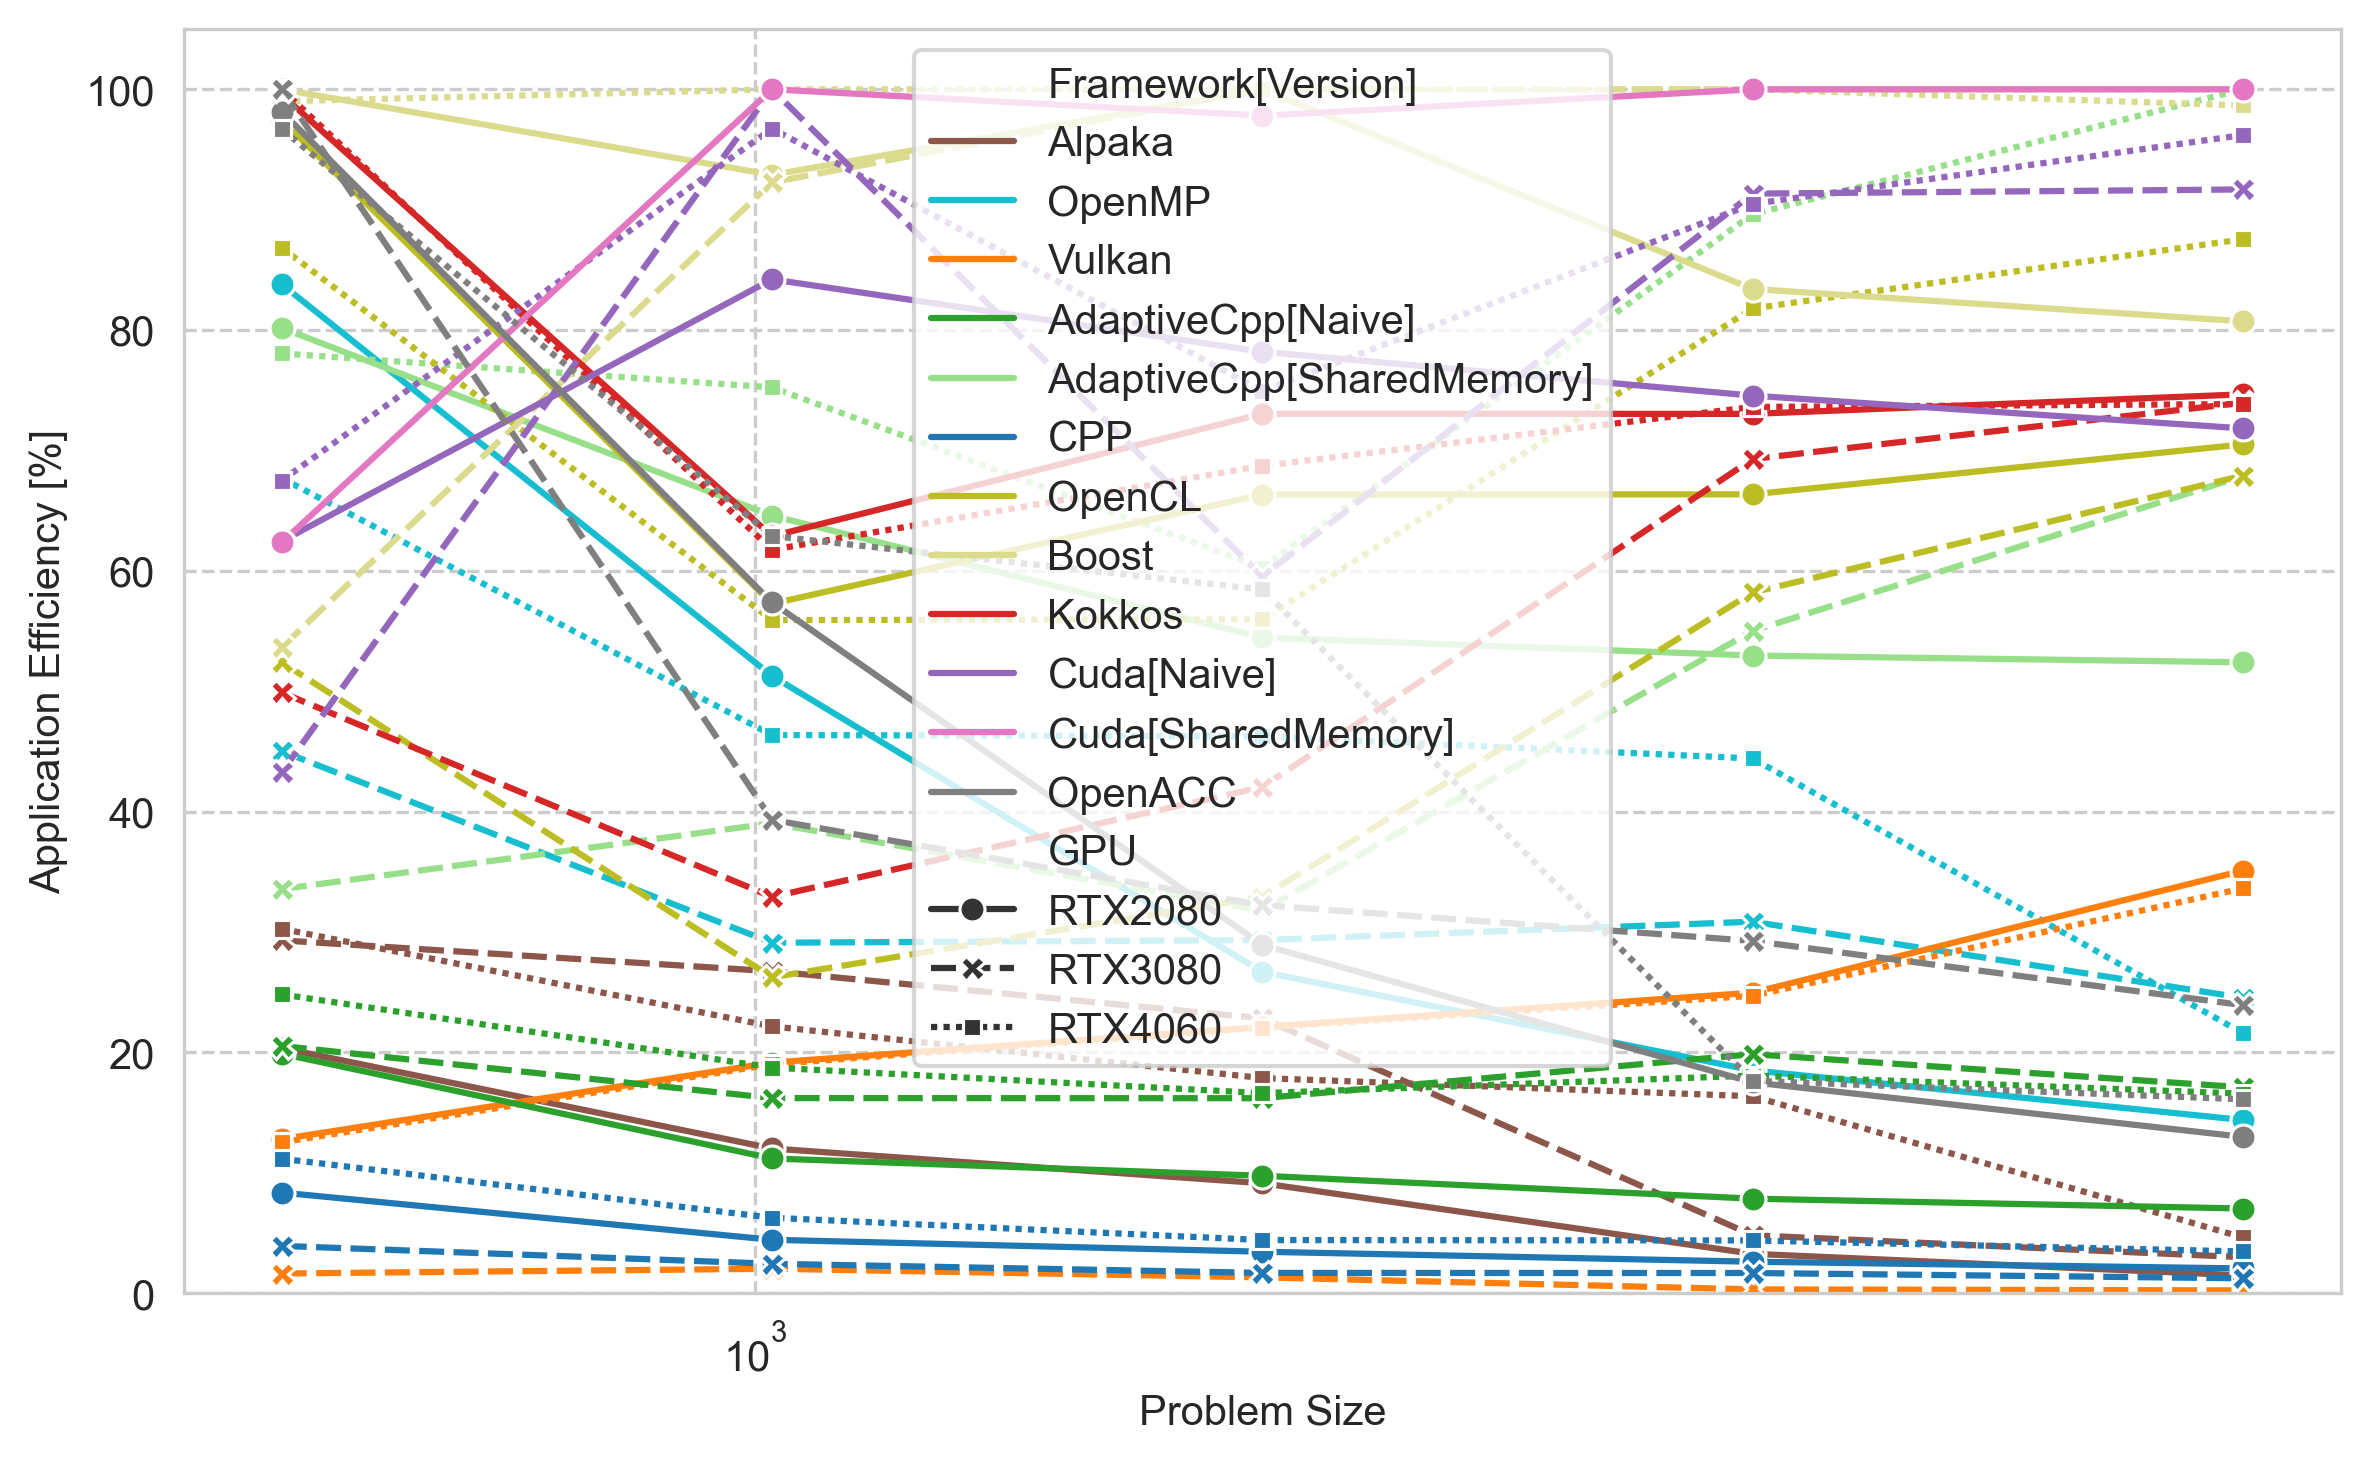

In [8]:
palette = {k: color_map[k] for k in matMul_df["Framework[Version]"].unique() if k in color_map}

plt.figure(figsize=(8, 5))
ax = sns.lineplot(
    data=matMul_df,
    x="Problem Size",
    y="Application Efficiency [%]",
    hue="Framework[Version]",
    style="GPU",
    markers=True,
    dashes=True,
    palette=palette
)
ax.set_xscale("log")
ax.set_ylim(0, 105)
ax.set_xlabel("Problem Size")
ax.set_ylabel("Application Efficiency [%]")
ax.grid(True, linestyle="--")
plt.tight_layout()
plt.gcf().set_dpi(300)
plt.show()


/var/folders/d7/j4pv5c3d1nj5jmjlz_bpj2lh0000gn/T/ipykernel_99409/1329105401.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


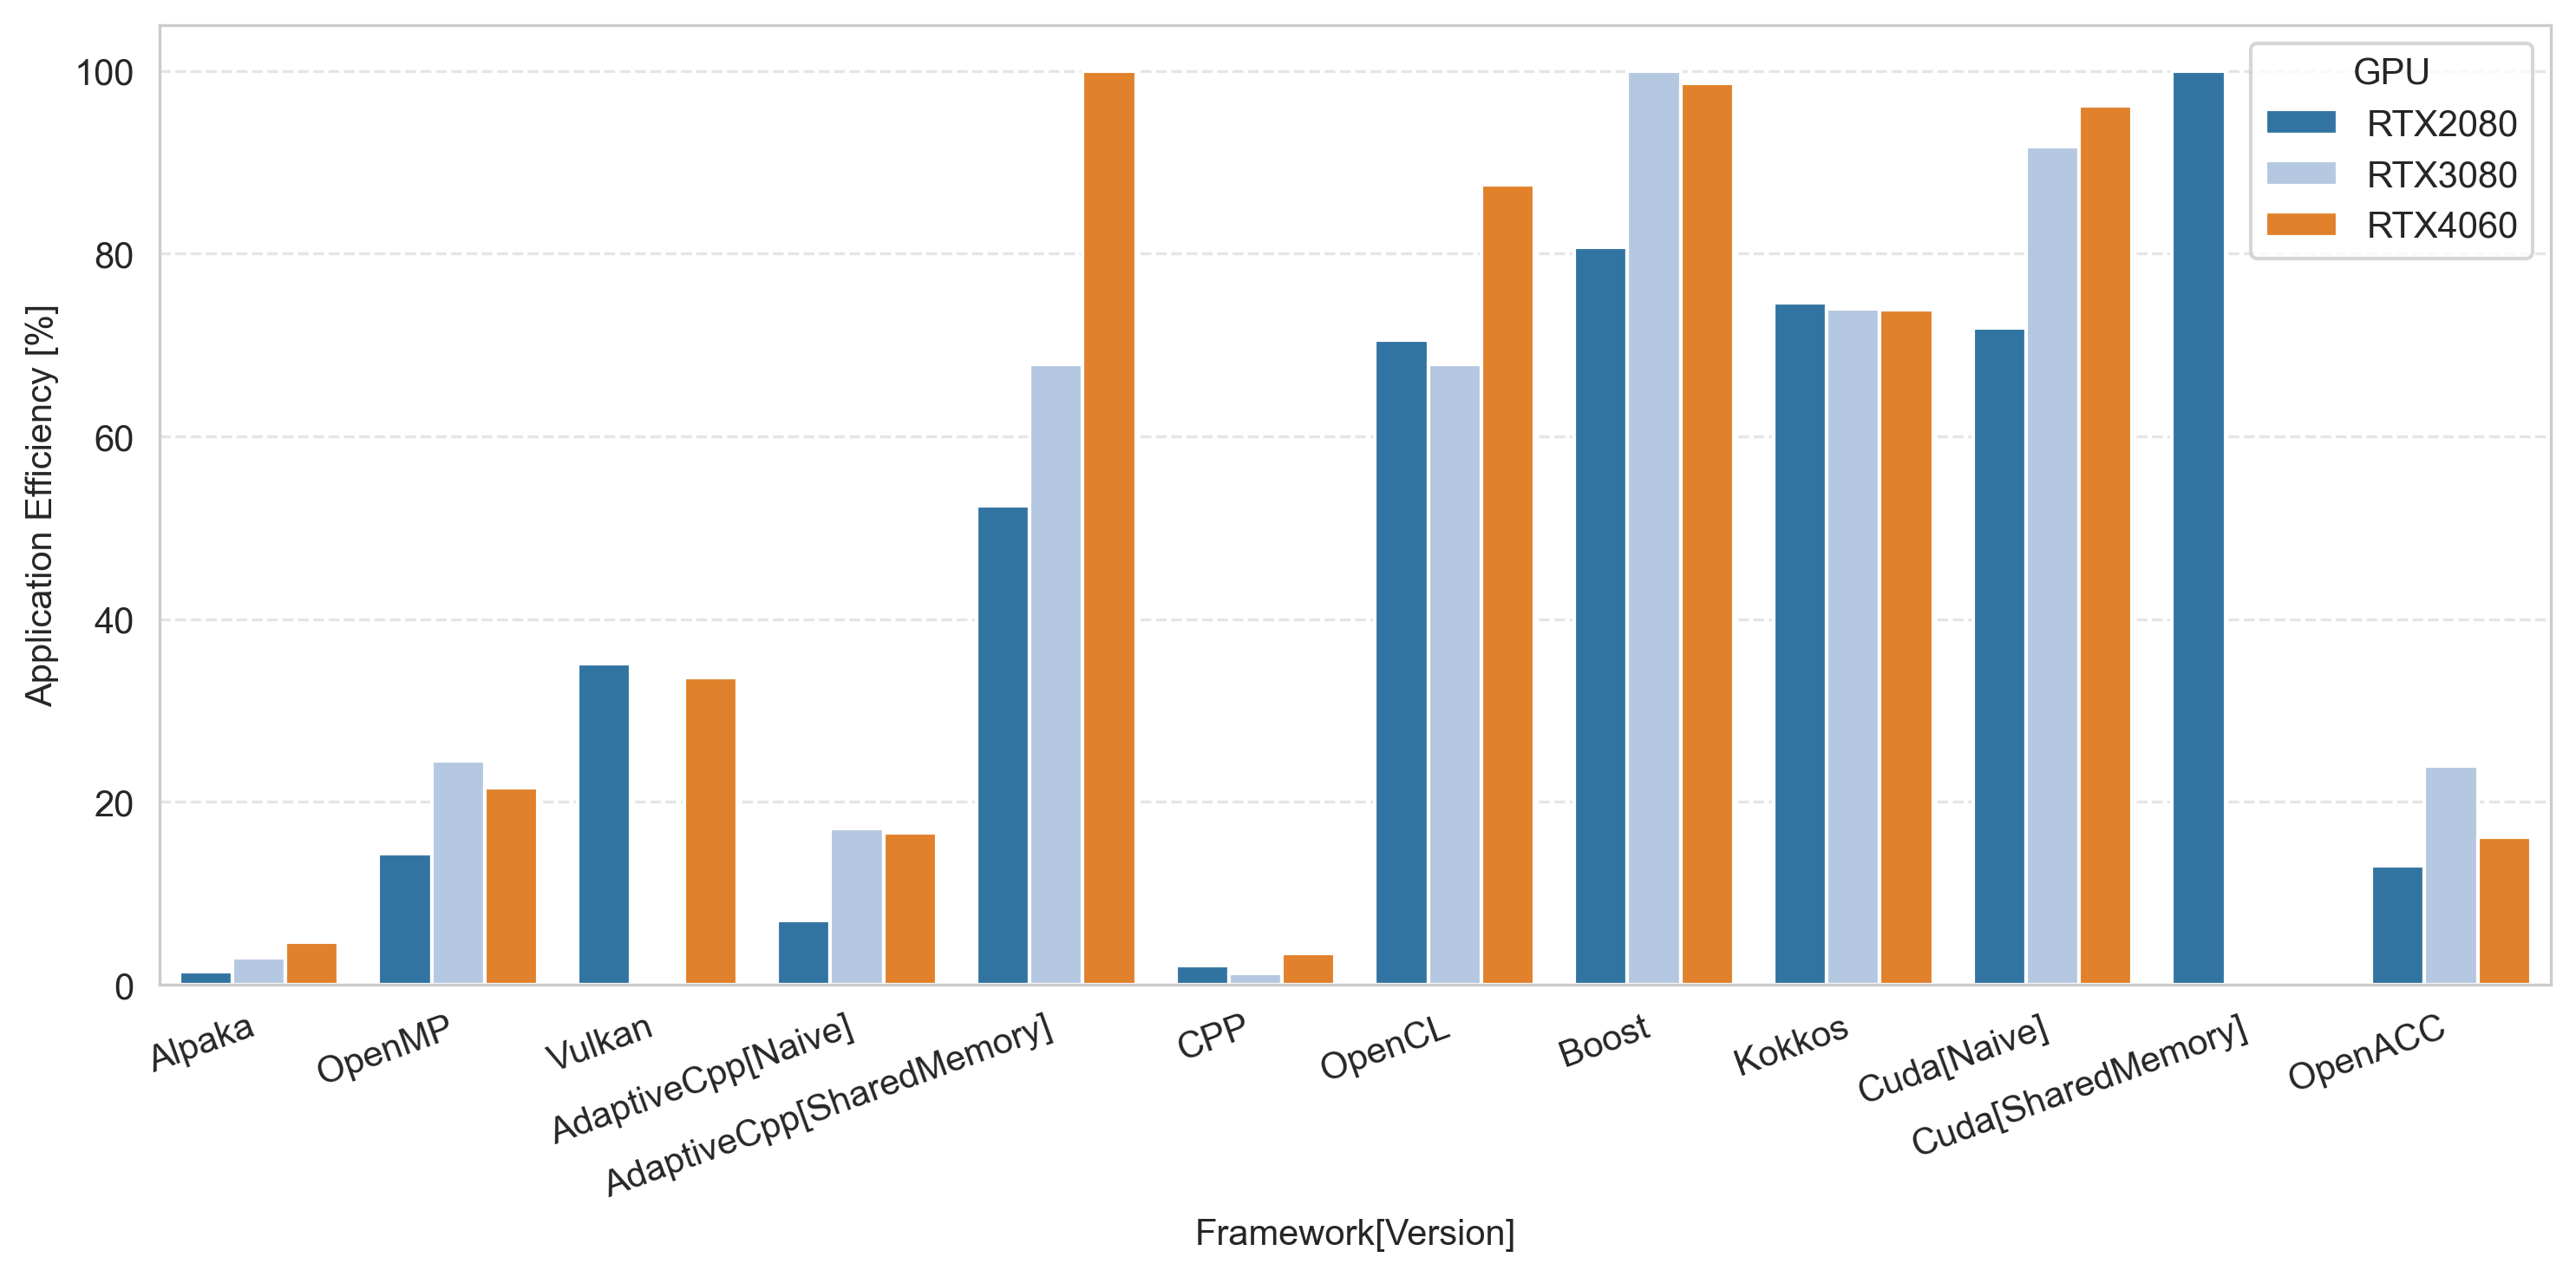

In [10]:
matMul_df_8192 = matMul_df.loc[matMul_df["Problem Size"] == 8192]
palette = {k: color_map[k] for k in matMul_df["Framework[Version]"].unique() if k in color_map}

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=matMul_df_8192,
    x="Framework[Version]",
    y="Application Efficiency [%]",
    hue="GPU",
    palette="tab20",
    ci=None
)
ax.set_ylim(0, 105)
ax.set_xlabel("Framework[Version]")
ax.set_ylabel("Application Efficiency [%]")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.gcf().set_dpi(300)
plt.show()


In [11]:
nbody_df = filter_and_concat(
    df=df,
    queries=[
        ("NBody", 100, "Wall Clock Time"),
        ("NBody", 1000, "Wall Clock Time"),
        ("NBody", 10000, "Wall Clock Time"),
    ]
)

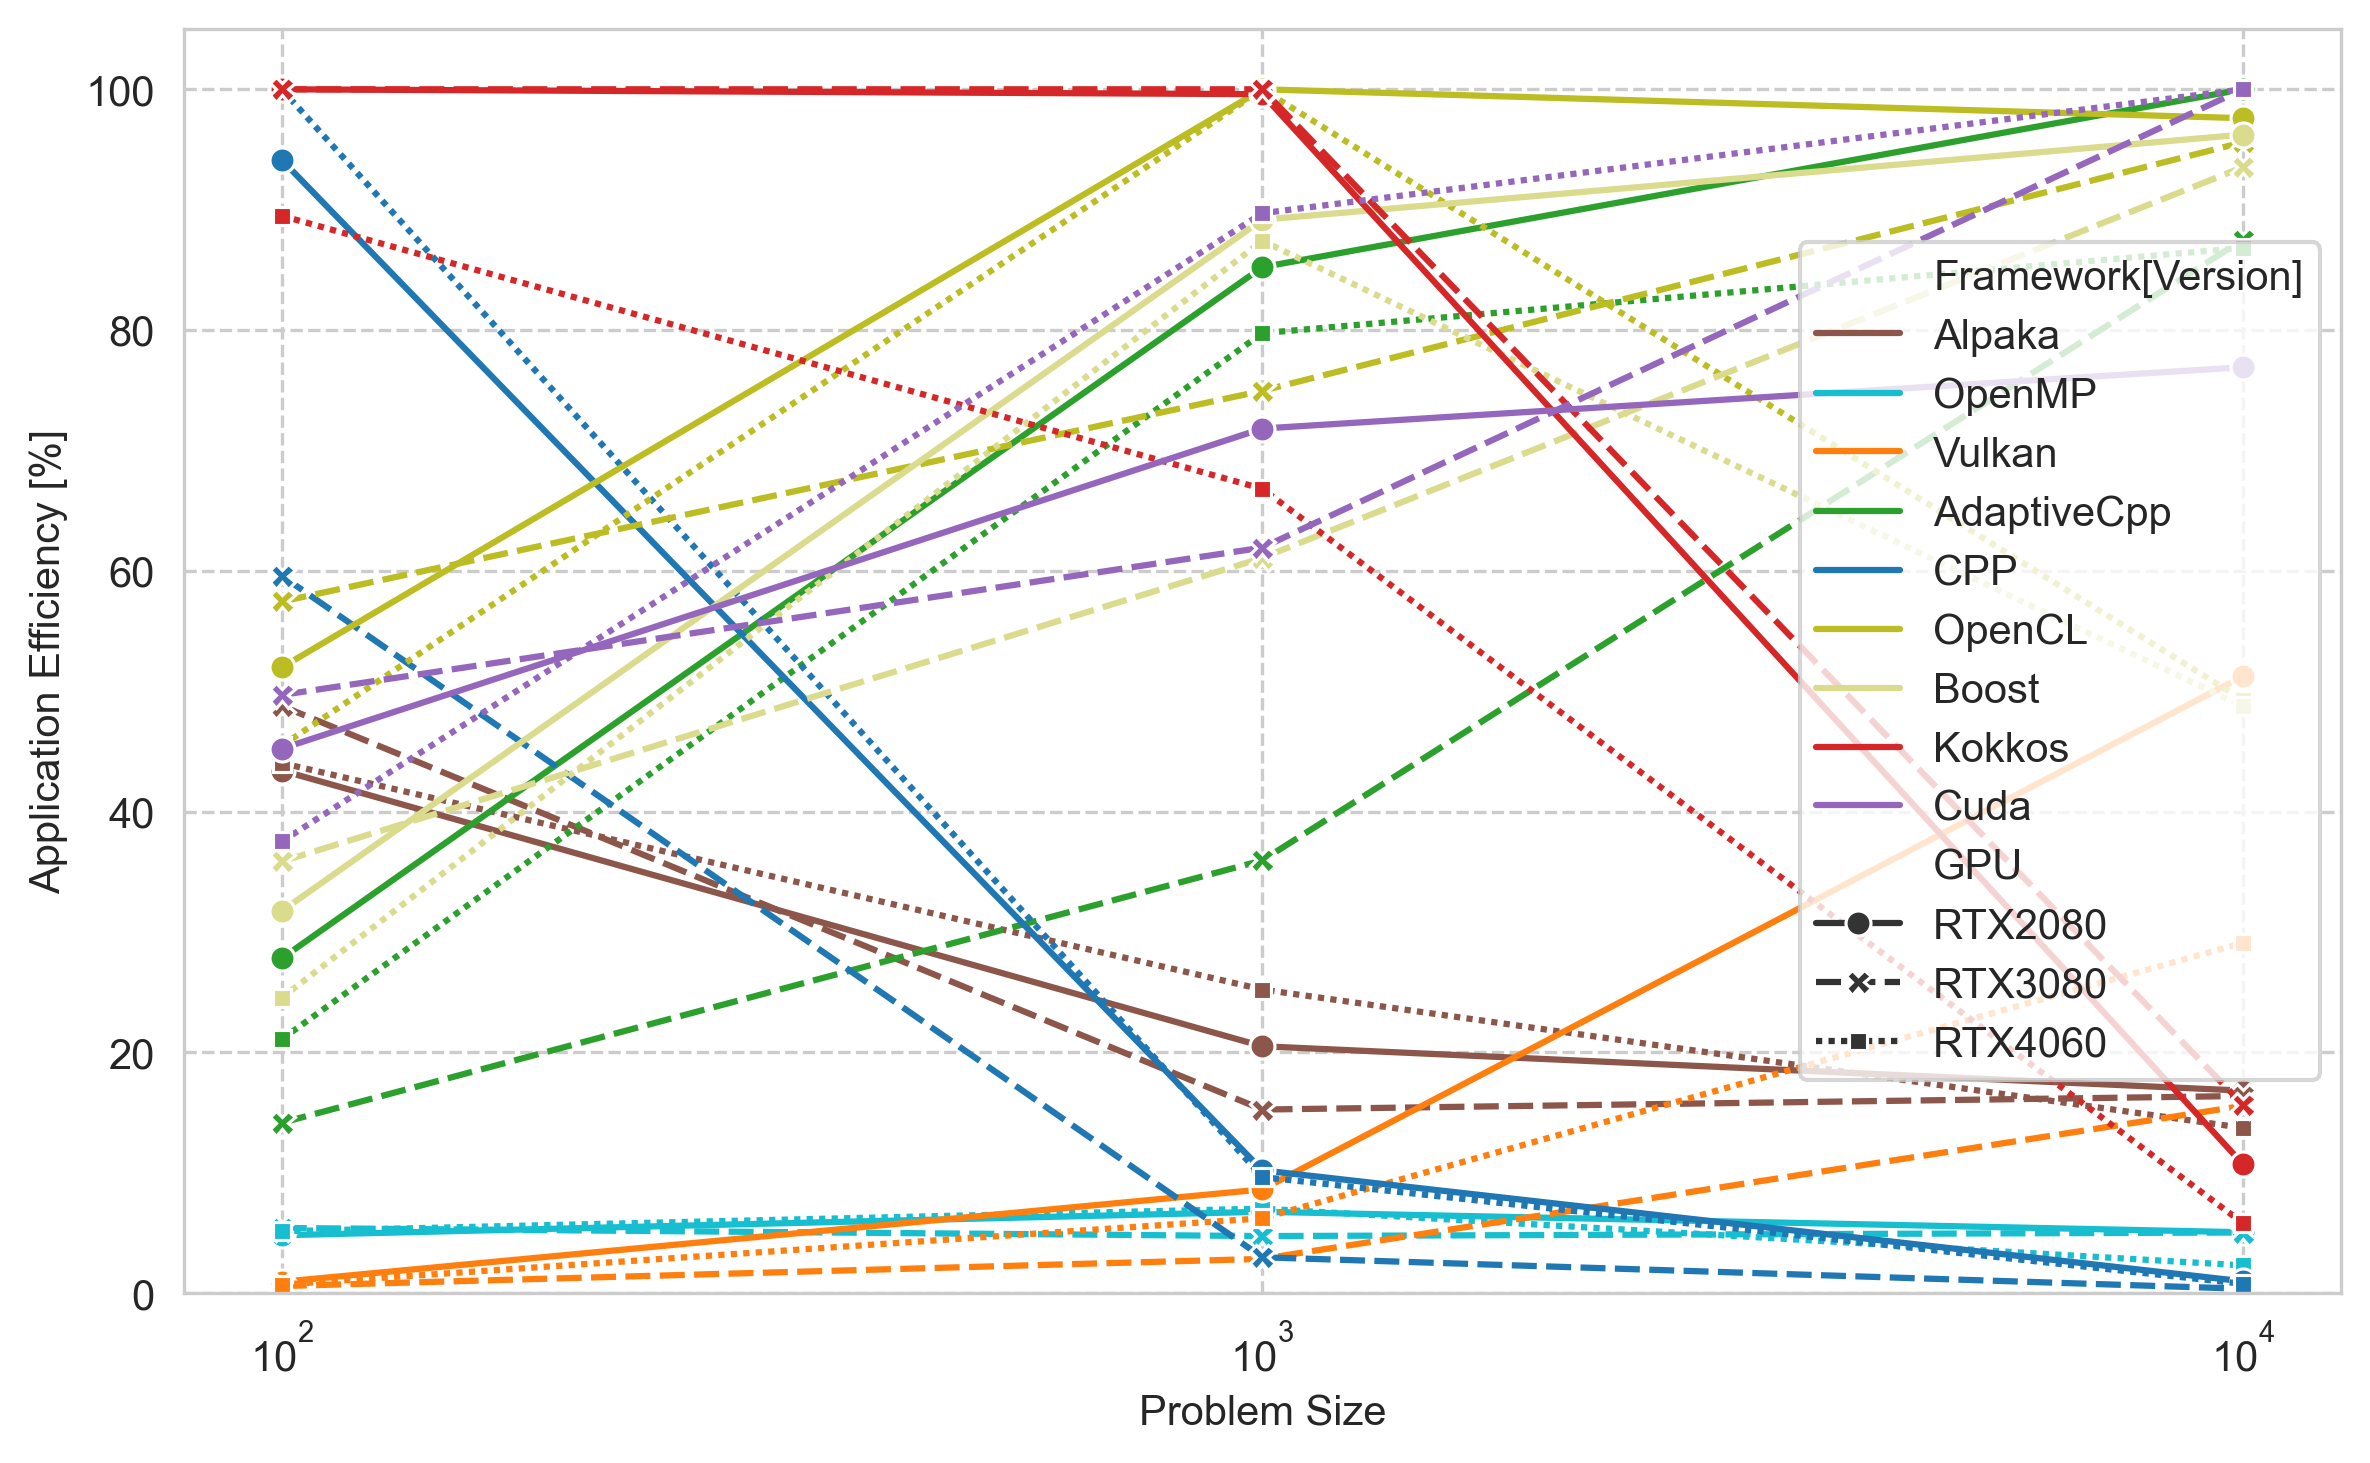

In [14]:
palette = {k: color_map[k] for k in nbody_df["Framework[Version]"].unique() if k in color_map}

plt.figure(figsize=(8, 5))
ax = sns.lineplot(
    data=nbody_df,
    x="Problem Size",
    y="Application Efficiency [%]",
    hue="Framework[Version]",
    style="GPU",
    markers=True,
    dashes=True,
    palette=palette
)
ax.set_xscale("log")
ax.set_ylim(0, 105)
ax.set_xlabel("Problem Size")
ax.set_ylabel("Application Efficiency [%]")
ax.grid(True, linestyle="--")
plt.tight_layout()
plt.gcf().set_dpi(300)
plt.show()


/var/folders/d7/j4pv5c3d1nj5jmjlz_bpj2lh0000gn/T/ipykernel_99409/1847924073.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


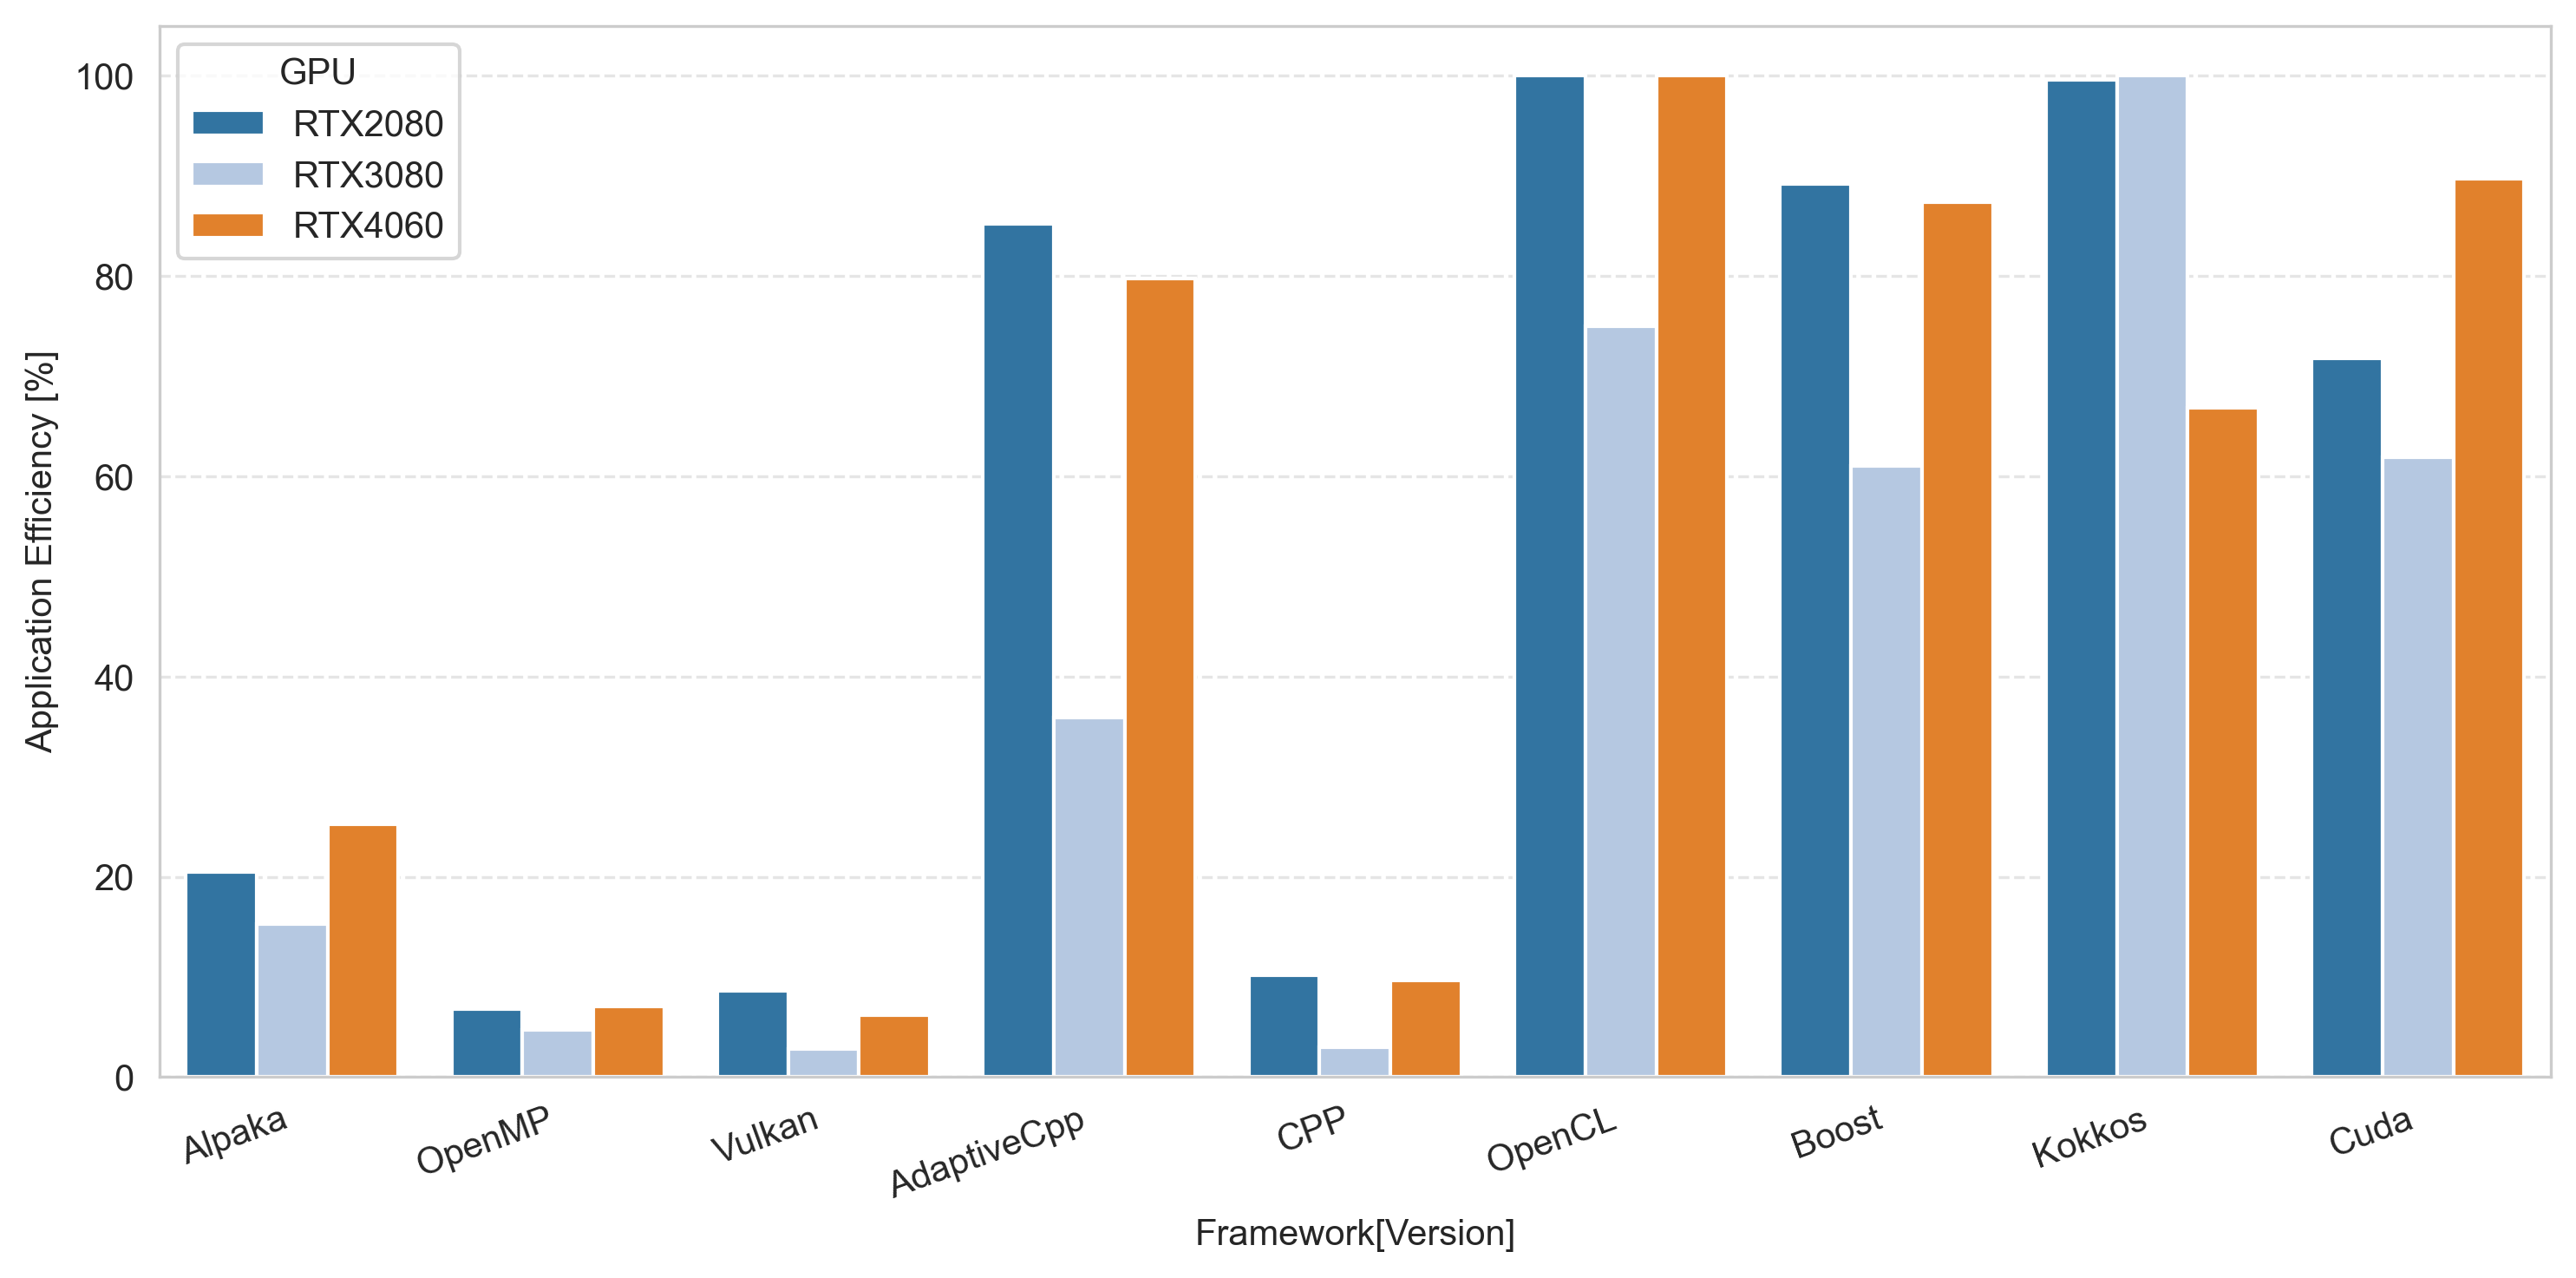

In [17]:
nbody_df_1k = nbody_df.loc[nbody_df["Problem Size"] == 1000]
palette = {k: color_map[k] for k in nbody_df["Framework[Version]"].unique() if k in color_map}

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=nbody_df_1k,
    x="Framework[Version]",
    y="Application Efficiency [%]",
    hue="GPU",
    palette="tab20",
    ci=None
)
ax.set_ylim(0, 105)
ax.set_xlabel("Framework[Version]")
ax.set_ylabel("Application Efficiency [%]")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.gcf().set_dpi(300)
plt.show()

/var/folders/d7/j4pv5c3d1nj5jmjlz_bpj2lh0000gn/T/ipykernel_99409/203284038.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


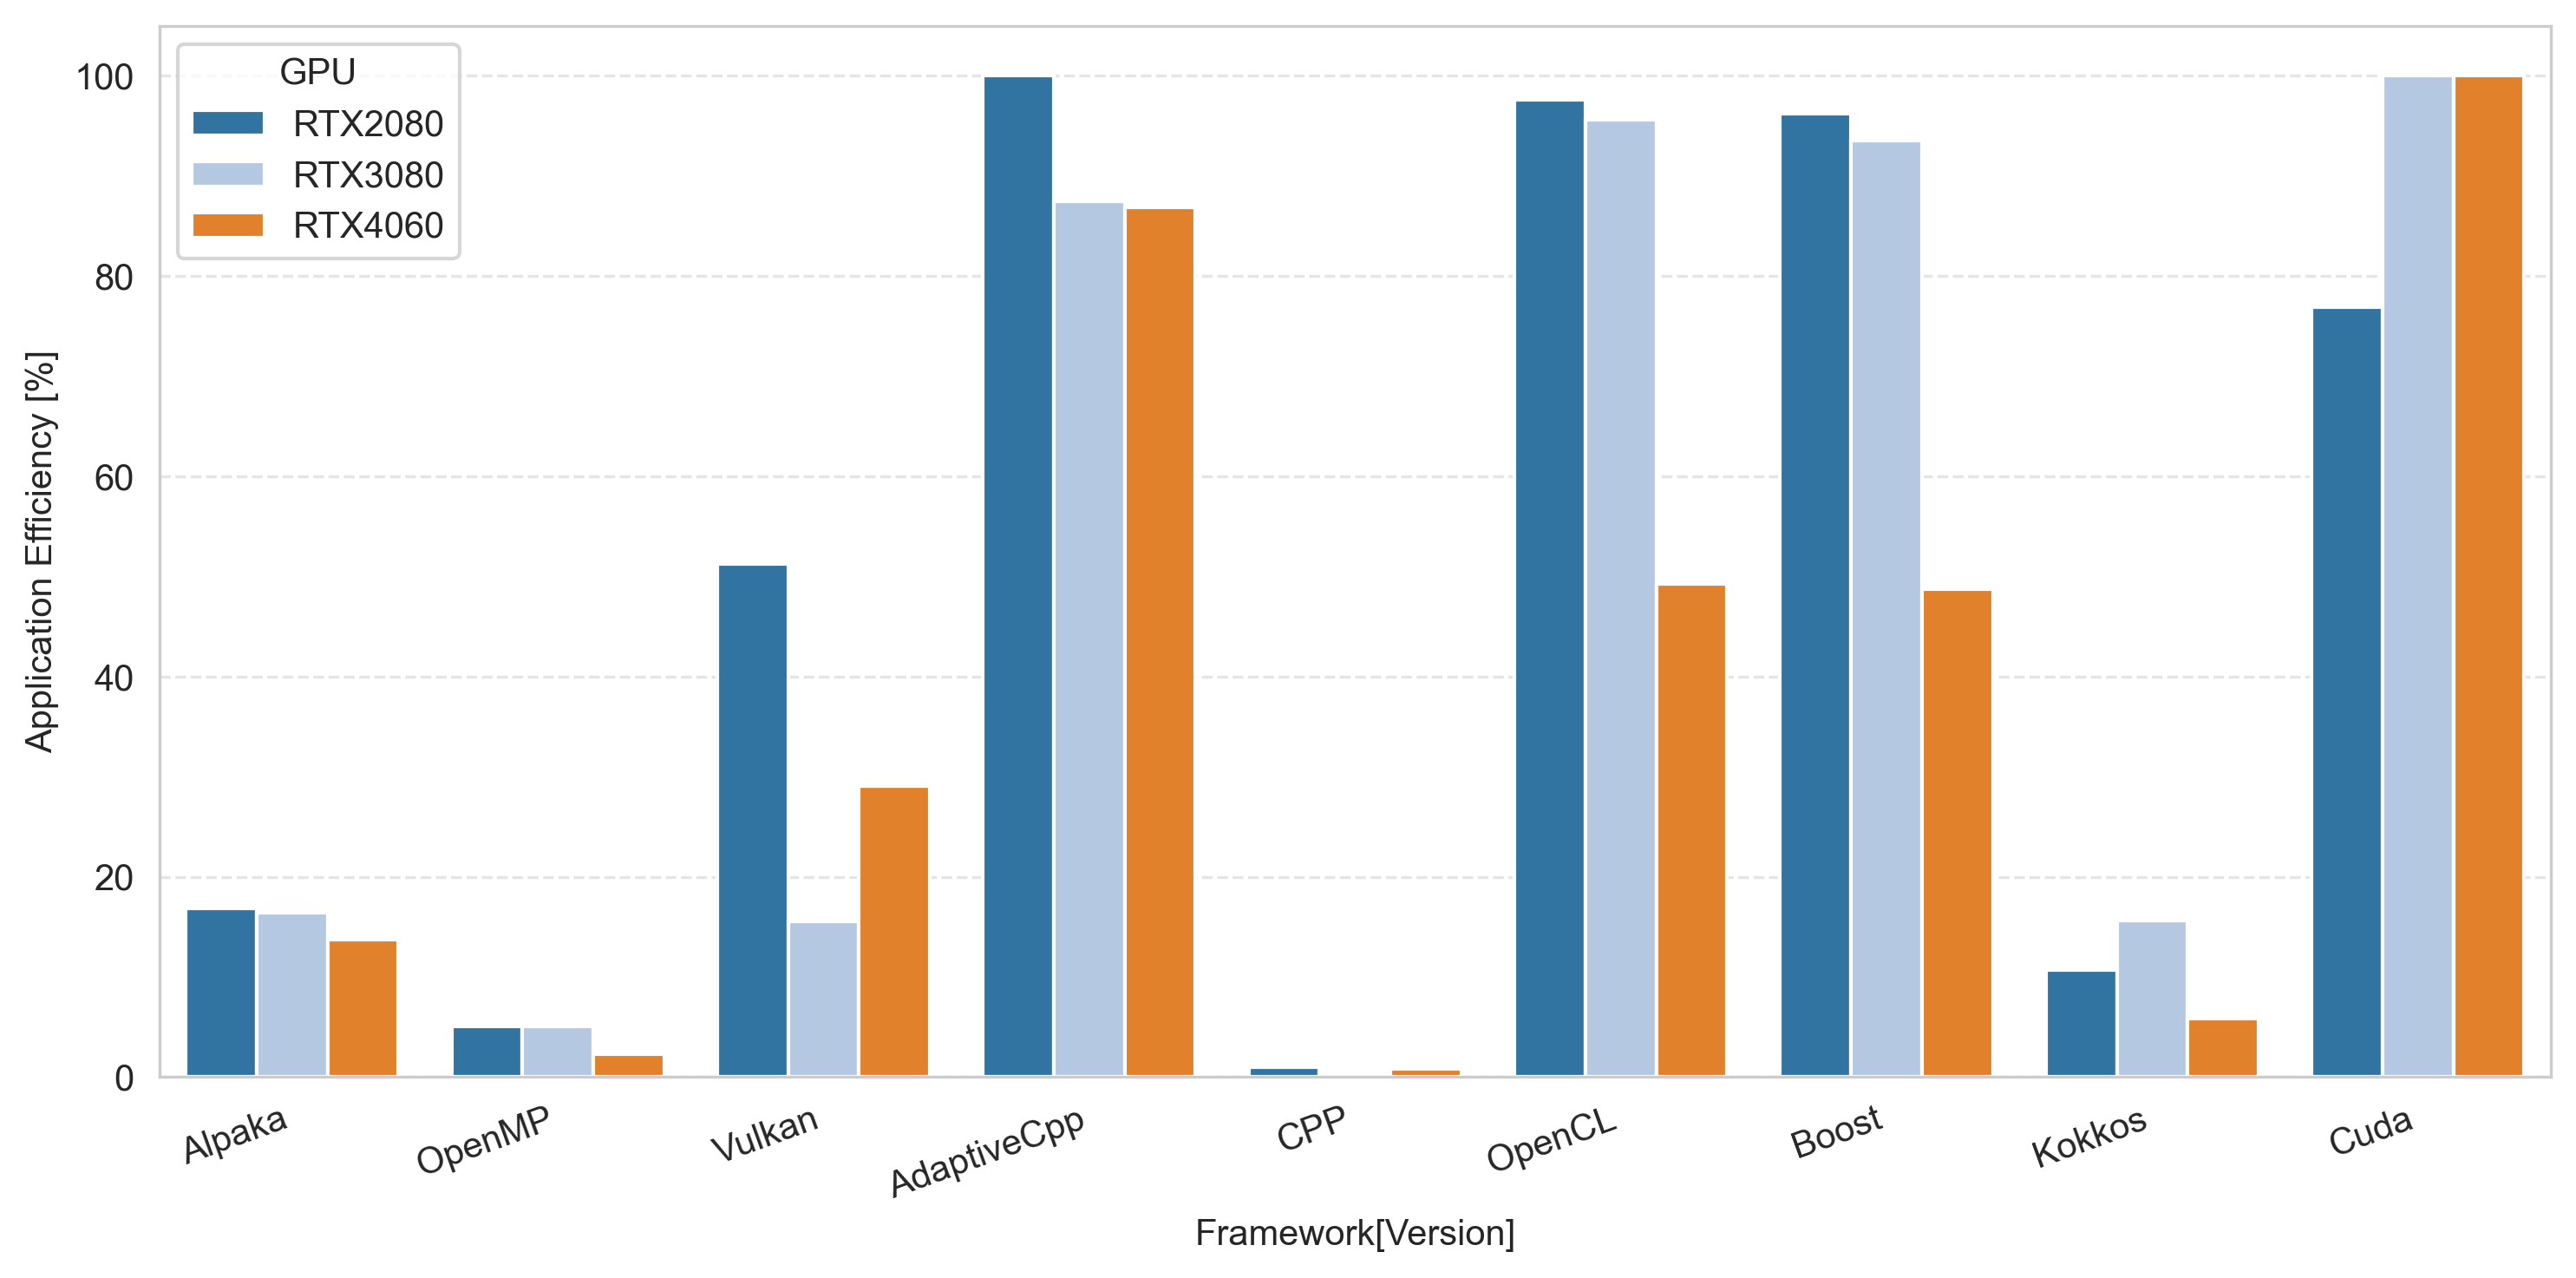

In [18]:
nbody_df_10k = nbody_df.loc[nbody_df["Problem Size"] == 10000]
palette = {k: color_map[k] for k in nbody_df["Framework[Version]"].unique() if k in color_map}

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=nbody_df_10k,
    x="Framework[Version]",
    y="Application Efficiency [%]",
    hue="GPU",
    palette="tab20",
    ci=None
)
ax.set_ylim(0, 105)
ax.set_xlabel("Framework[Version]")
ax.set_ylabel("Application Efficiency [%]")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.gcf().set_dpi(300)
plt.show()